In [1]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c rossmann-store-sales
!unzip rossmann-store-sales.zip

100% 6.99M/6.99M [00:00<00:00, 67.9MB/s]

Archive:  rossmann-store-sales.zip
  inflating: sample_submission.csv   
  inflating: store.csv               
  inflating: test.csv                
  inflating: train.csv               


In [3]:
import pandas as pd
train = pd.read_csv('train.csv', low_memory=False)
store = pd.read_csv('store.csv', low_memory=False)
print("train shape:", train.shape)
print("store shape:", store.shape)

train shape: (1017209, 9)
store shape: (1115, 10)


In [4]:
!kaggle competitions download -c rossmann-store-sales
!unzip rossmann-store-sales.zip

rossmann-store-sales.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  rossmann-store-sales.zip
replace sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: no
replace store.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: no
replace test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: no
replace train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: no


In [5]:
import pandas as pd
train = pd.read_csv('train.csv', low_memory=False)
store = pd.read_csv('store.csv', low_memory=False)
print("train shape:", train.shape)
print("store shape:", store.shape)
print("\nTrain columns",train.columns.tolist())
train.head()

train shape: (1017209, 9)
store shape: (1115, 10)

Train columns ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
%matplotlib inline

print('libraries loaded')

libraries loaded


In [7]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [8]:
print(train.info())
print(train.isnull().sum())
print(store.info())
print(store.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB
None
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count

In [9]:
df = pd.merge(train, store, on='Store',how = 'left')
print('merged shape:',df.shape)
df.head()


merged shape: (1017209, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [10]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
print(df[['Date','Year','Month','Day','WeekOfYear']].head())

        Date  Year  Month  Day  WeekOfYear
0 2015-07-31  2015      7   31          31
1 2015-07-31  2015      7   31          31
2 2015-07-31  2015      7   31          31
3 2015-07-31  2015      7   31          31
4 2015-07-31  2015      7   31          31


In [11]:
df = df[(df['Open'] == 1) & (df['Sales']>0)]
print("shape after removing closed stores:", df.shape)

shape after removing closed stores: (844338, 22)


In [12]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,2015,7,31,31
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN,2015,7,31,31
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN,2015,7,31,31


In [13]:
print("Average Daily sales:", df['Sales'].mean().round(2))
print("maximum sales:",df['Sales'].max())
print("minimum sales:",df['Sales'].min())

Average Daily sales: 6955.96
maximum sales: 41551
minimum sales: 46


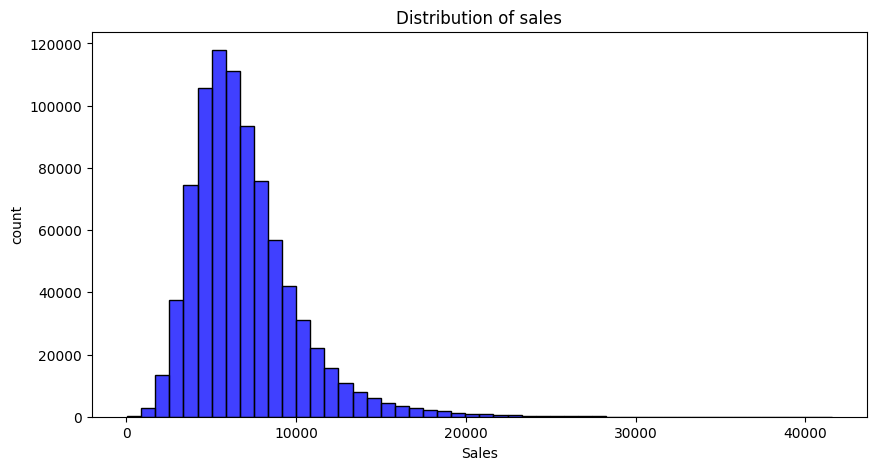

In [14]:
plt.figure(figsize = (10,5))
sns.histplot(df['Sales'],bins = 50,color = 'blue')
plt.title('Distribution of sales')
plt.xlabel('Sales')
plt.ylabel('count')
plt.show()

In [15]:
store.describe()

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


/tmp/ipykernel_3050/1519006289.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = monthly_sales.index, y = monthly_sales.values, palette = 'viridis')


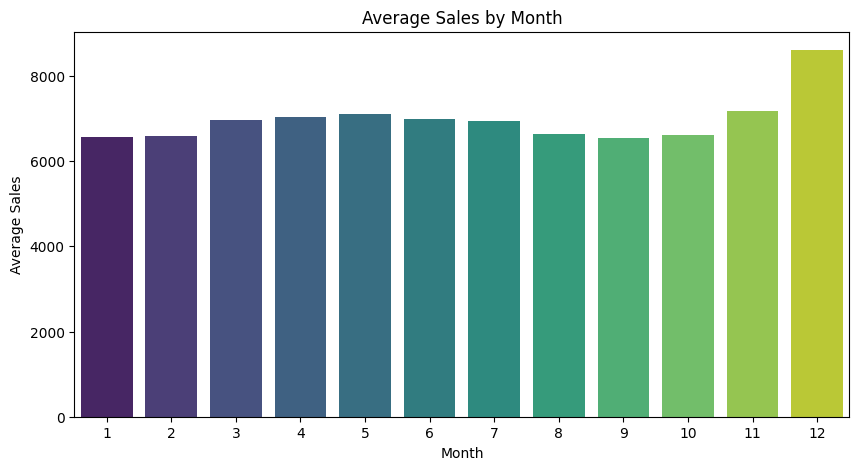

In [16]:
monthly_sales = df.groupby('Month')['Sales'].mean()

plt.figure(figsize = (10,5))
sns.barplot(x = monthly_sales.index, y = monthly_sales.values, palette = 'viridis')
plt.title('Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.show()

/tmp/ipykernel_3050/4026953377.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="DayOfWeek",y= "Sales", data = df,palette = "Greens_d")


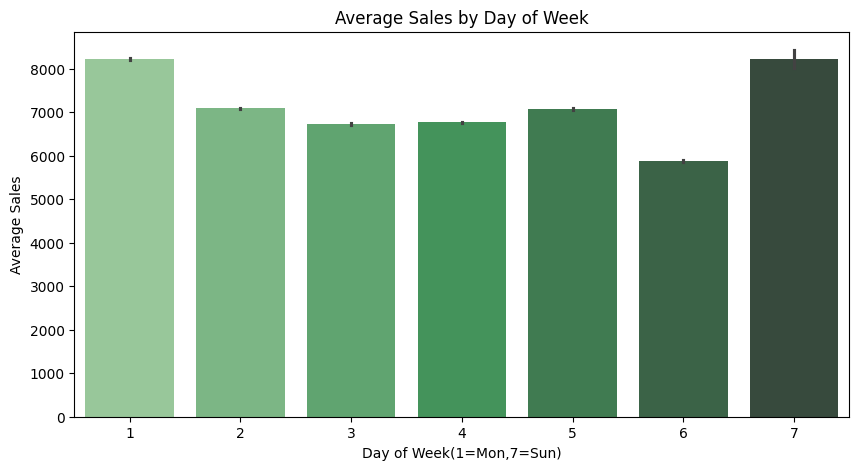

In [17]:
plt.figure(figsize = (10,5))
sns.barplot(x="DayOfWeek",y= "Sales", data = df,palette = "Greens_d")
plt.title('Average Sales by Day of Week')
plt.xlabel('Day of Week(1=Mon,7=Sun)')
plt.ylabel('Average Sales')
plt.show()




In [18]:
df.tail()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
1016776,682,2,2013-01-01,3375,566,1,0,a,1,b,a,150.0,9.0,2006.0,0,NaN,NaN,NaN,2013,1,1,1
1016827,733,2,2013-01-01,10765,2377,1,0,a,1,b,b,860.0,10.0,1999.0,0,NaN,NaN,NaN,2013,1,1,1
1016863,769,2,2013-01-01,5035,1248,1,0,a,1,b,b,840.0,NaN,NaN,1,48.0,2012.0,"Jan,Apr,Jul,Oct",2013,1,1,1
1017042,948,2,2013-01-01,4491,1039,1,0,a,1,b,b,1430.0,NaN,NaN,0,NaN,NaN,NaN,2013,1,1,1
1017190,1097,2,2013-01-01,5961,1405,1,0,a,1,b,b,720.0,3.0,2002.0,0,NaN,NaN,NaN,2013,1,1,1


/tmp/ipykernel_3050/1679270722.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Promo',y='Sales',data = df,palette = 'Reds_d')


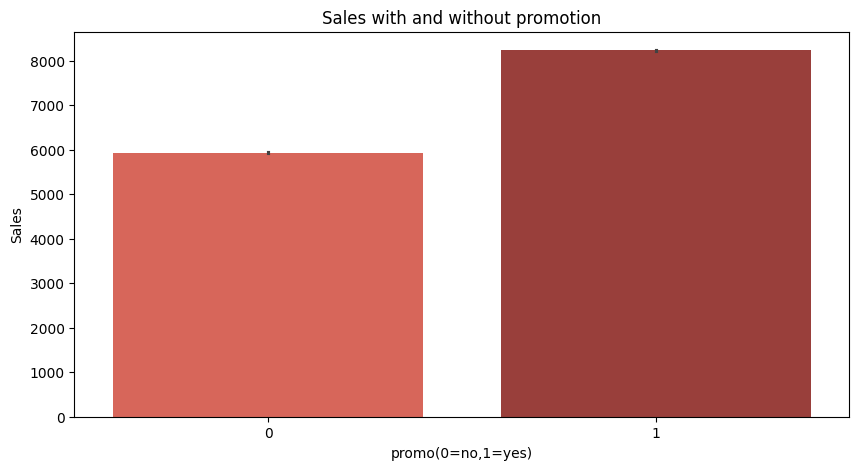

In [19]:
plt.figure(figsize = (10,5))
sns.barplot(x='Promo',y='Sales',data = df,palette = 'Reds_d')
plt.title('Sales with and without promotion')
plt.xlabel('promo(0=no,1=yes)')
plt.ylabel('Sales')
plt.show()

In [20]:
print("Missing values in df:")
print(df.isnull().sum())

Missing values in df:
Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2186
CompetitionOpenSinceMonth    268600
CompetitionOpenSinceYear     268600
Promo2                            0
Promo2SinceWeek              423292
Promo2SinceYear              423292
PromoInterval                423292
Year                              0
Month                             0
Day                               0
WeekOfYear                        0
dtype: int64


In [21]:
df.shape

(844338, 22)

In [22]:
df['CompetitionDistance'].fillna(df['CompetitionDistance'].median(),inplace = True)
df['CompetitionOpenSinceMonth'].fillna(0,inplace = True)
df['CompetitionOpenSinceYear'].fillna(0,inplace = True)
df['Promo2SinceWeek'].fillna(0,inplace = True)
df['Promo2SinceYear'].fillna(0,inplace = True)
df['PromoInterval'].fillna('None',inplace = True)
print('missing values after cleaning')
print(df.isnull().sum())

/tmp/ipykernel_3050/1389663392.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CompetitionDistance'].fillna(df['CompetitionDistance'].median(),inplace = True)
/tmp/ipykernel_3050/1389663392.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col]

missing values after cleaning
Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
Year                         0
Month                        0
Day                          0
WeekOfYear                   0
dtype: int64


In [23]:
print(df.dtypes)

Store                                 int64
DayOfWeek                             int64
Date                         datetime64[ns]
Sales                                 int64
Customers                             int64
Open                                  int64
Promo                                 int64
StateHoliday                         object
SchoolHoliday                         int64
StoreType                            object
Assortment                           object
CompetitionDistance                 float64
CompetitionOpenSinceMonth           float64
CompetitionOpenSinceYear            float64
Promo2                                int64
Promo2SinceWeek                     float64
Promo2SinceYear                     float64
PromoInterval                        object
Year                                  int32
Month                                 int32
Day                                   int32
WeekOfYear                            int64
dtype: object


In [24]:
df.drop(['Customers'],axis = 1,inplace = True)
print("shape after removing customers column",df.shape)

shape after removing customers column (844338, 21)


In [25]:
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x:1 if x in [6,7] else 0)
df['MonthPart'] = df['Day'].apply(lambda x:1 if x <= 10 else(2 if x<=20 else 3))
print(df[['DayOfWeek','IsWeekend','Day','MonthPart']].head(20))

    DayOfWeek  IsWeekend  Day  MonthPart
0           5          0   31          3
1           5          0   31          3
2           5          0   31          3
3           5          0   31          3
4           5          0   31          3
5           5          0   31          3
6           5          0   31          3
7           5          0   31          3
8           5          0   31          3
9           5          0   31          3
10          5          0   31          3
11          5          0   31          3
12          5          0   31          3
13          5          0   31          3
14          5          0   31          3
15          5          0   31          3
16          5          0   31          3
17          5          0   31          3
18          5          0   31          3
19          5          0   31          3


In [26]:
df['CompetitionOpen'] = 12*(df['Year'] - df['CompetitionOpenSinceYear']) + (df['Month'] - df['CompetitionOpenSinceMonth'])
df['CompetitionOpen'] = df['CompetitionOpen'].apply(lambda x:x if x>0 else 0)
print(df[['CompetitionOpen']].head(10))

   CompetitionOpen
0             82.0
1             92.0
2            103.0
3             70.0
4              3.0
5             19.0
6             27.0
7              9.0
8            179.0
9             70.0


In [27]:
df['Promo2Open'] = 12*(df['Year'] - df['Promo2SinceYear']) + (df['WeekOfYear'] - df['Promo2SinceWeek'])/4.0
df['Promo2Open'] = df['Promo2Open'].apply(lambda x:x if x>0 else 0)
print(df[['Promo2Open']].head(10))

   Promo2Open
0    24187.75
1       64.50
2       52.25
3    24187.75
4    24187.75
5    24187.75
6    24187.75
7    24187.75
8    24187.75
9    24187.75


In [28]:
features = ['Store','DayOfWeek','Promo','StateHoliday','SchoolHoliday','StoreType','Assortment','CompetitionDistance','Year','Month','Day','WeekOfYear','IsWeekend',
            'MonthPart','CompetitionOpen','Promo2','Promo2Open']

In [29]:
target  = 'Sales'
X = df[features]
y = df[target]
print("X shape :", X.shape)
print("y shape:", y.shape)

X shape : (844338, 17)
y shape: (844338,)


In [30]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X['StateHoliday'] = le.fit_transform(X['StateHoliday'].astype(str))
X['StoreType'] = le.fit_transform(X['StoreType'].astype(str))
X['Assortment'] = le.fit_transform(X['Assortment'].astype(str))
print("Encoding done")

/tmp/ipykernel_3050/829238108.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['StateHoliday'] = le.fit_transform(X['StateHoliday'].astype(str))
/tmp/ipykernel_3050/829238108.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['StoreType'] = le.fit_transform(X['StoreType'].astype(str))


Encoding done


/tmp/ipykernel_3050/829238108.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Assortment'] = le.fit_transform(X['Assortment'].astype(str))


In [31]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)
print('X-train shape:',X_train.shape)
print('X_test shape:',X_test.shape)


X-train shape: (675470, 17)
X_test shape: (168868, 17)


In [33]:
from sklearn.ensemble import RandomForestRegressor

X_train_small = X_train.sample(n=100000, random_state=42)
y_train_small = y_train[X_train_small.index]
model = RandomForestRegressor(n_estimators = 50, random_state = 42,n_jobs = -1)
model.fit(X_train,y_train)

print('model training done')

model training done


In [34]:
y_pred = model.predict(X_test)
print('predictions done')
print('sample predictions',y_pred[:5])
print("actual values",y_test[:5].values)

predictions done
sample predictions [6206.1  9184.44 9885.68 9730.6  8835.1 ]
actual values [ 5934  7800  9111  7831 10046]


In [35]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np

mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)
print("mae",round(mae,2))
print("rmse",round(rmse,2))
print("R2 score",round(r2,4))



mae 590.66
rmse 922.98
R2 score 0.9117


In [36]:
import joblib

joblib.dump(model,'demand_forecast_model.pkl')
print('model saved')

model saved


In [37]:
import joblib
loaded_model = joblib.load('demand_forecast_model.pkl')
print('model loaded')

test_pred = loaded_model.predict(X_test)
print('test preictions', test_pred)

model loaded
test preictions [6206.1  9184.44 9885.68 ... 6723.18 3750.06 5734.22]


In [38]:
from google.colab import files
files.download('demand_forecast_model.pkl')
print('Model downloaded')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model downloaded


In [39]:
!pip install gradio

In [3]:
import gradio as gr
import joblib
import numpy as np

model = joblib.load('demand_forecast_model.pkl')
def predict_sales(Store, DayOfWeek,Promo,SchoolHoliday,CompetitionDisatnce,Year,Month,Day):
  features = np.array([[Store, DayOfWeek, Promo, 0, SchoolHoliday, 0, 0, CompetitionDisatnce, 0,Year,Month,Day,1,0,1,0,0]])
  prediction = model.predict(features)
  return f"Predicted Sales:dollar {round(prediction[0],2)}"

app = gr.Interface(
    fn = predict_sales,
    inputs = [
        gr.Number(label = "Store ID"),
        gr.Slider(1,7,step = 1,label = "Day of Week(1=Mon,7=Sun)"),
        gr.Radio([0,1],label = "Promo(0=No,1=yes)"),
        gr.Radio([0,1],label = "School Holiday(0=No,1=yes)"),
        gr.Number(label = "Competition Distance(meters)"),
        gr.Number(label = "Year(eg.2025)"),
        gr.Slider(1,12,step = 1,label = "Month"),
        gr.Slider(1,31,step=1,label = "Day"),


    ],
    outputs = gr.Textbox(label = "Prediction"),
    title = "Rossmann Sales Predictor",
    description = "Enter store details to predict daily sales!"
)

app.launch(share = True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2d6d5033423f5de396.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
